In [10]:
import pickle as pkl
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 
import numpy as np
import matplotlib as mpl

from collections import defaultdict, Counter
import seaborn as sns

from tqdm import tqdm
from pathlib import Path 

plt.rcParams["figure.dpi"] = 150

In [11]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)


In [12]:
ak_clusters = pd.read_csv("/home/wuhlmann/BA/data/processed_data/CA/ak_clusters.csv", header=0, sep=";")
lamah_gdf["ak_clusters"] = ak_clusters["cluster"]

### SA

In [13]:
nse_path = Path("/home/wuhlmann/BA/data/processed_data/CA/NSE_deltas")

model_name = "q_pred_landcover_0903_135428"

nse_file_list = list(nse_path.glob(f"{model_name}*.p"))

nse_dict = {} 


In [14]:
for nse_path in nse_file_list: 
	
	with open(nse_path, "rb") as f: 
		nse_dict.update(pkl.load(f))
	
nse_dict = dict(sorted(nse_dict.items(), key=lambda item: int(item[0])))

In [15]:
nse_dict.keys()

dict_keys(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159

In [16]:
for b_id in nse_dict: 
	
	# sort index of all basin_df to alphabetical, as this was forgotten, when writing the SA code
	
	nse_dict[b_id].set_index(nse_dict[b_id].index.sort_values(),inplace=True)

In [17]:
# Calculate normalized variance of nse deltas for given noise range over all basins. 

max_pos_nse_deltas = []
mean_nse_delta = []
max_neg_nse_deltas = []

# inspect +/- impact on attr
dec_alt_impact = defaultdict(list)
inc_alt_impact = defaultdict(list) 
nse_diff_attr_dict = defaultdict(list)

noise_bounds = [0, 0.01, 0.1, 0.25, 0.5, 1]

noise_level_att_ranking = defaultdict(dict) # ranking of attr for noise ranges
noise_level_nse_var = defaultdict(list) # dict with attr+noise level as keys, and list of len 859 per key, with variance for that attribute and level for that basin

top_ranked_attr = {} # ranking of attributes over all noise levels
ranking_attr= {} # ranking of attributes over all noise levels
total_nse_var = defaultdict(list) #dict with attr as keys, and list of len 859, with variance over all noise levels per basins

for id in tqdm(list(nse_dict.keys())):
	

	# Get df.
	basin_df = nse_dict[id]
	
	max_pos_nse_deltas.append(basin_df.max().max())
	mean_nse_delta.append(basin_df.mean().mean())
	max_neg_nse_deltas.append(basin_df.min().min())
	
	basin_df = basin_df[basin_df<0]

	dec_attr_df = basin_df.loc[:, -1:0]
	inc_attr_df = basin_df.loc[:, 0:1]

	# get variances for each attribute, over all noise levels
	variances = basin_df.abs().var(axis=1)

	# normalize
	variances = (variances - variances.mean()) / variances.std()

	# rank highest varianve to lowest, and write into dict for ranking over all levels
	top_ranked_attr[id] = variances.sort_values(ascending=False).index[0]
	
	for rank, attr in enumerate(variances.sort_values(ascending=False).index):
		if attr not in ranking_attr:
			ranking_attr[attr] = []
		ranking_attr[attr].append(rank+1)

	# for each basins iterate all attr and append the total variances
	for attr in	variances.index: 
				
		total_nse_var[f"{attr}_nse_var"].append(variances.loc[attr])

		nse_diff_attr_dict[attr].append(basin_df.loc[attr, :].mean(skipna=True))

		dec_alt_impact[attr].append(dec_attr_df.loc[attr, :].mean(skipna=True))
		inc_alt_impact[attr].append(inc_attr_df.loc[attr, :].mean(skipna=True))

	for i in range(len(noise_bounds)-1): 

		lower_bound = noise_bounds[i]
		upper_bound = noise_bounds[i+1]

		# Get df.
		basin_df = nse_dict[id]

		# Filter df for specific noise range. 
		basin_df = basin_df.loc[:,lower_bound:upper_bound].join(basin_df.loc[:, -upper_bound:-lower_bound])

		variances = basin_df.abs().var(axis=1)

		variances = (variances - variances.mean()) / variances.std()

		noise_level_att_ranking[id][f"{upper_bound}_top"] = variances.sort_values(ascending=False).index[0]

		for attr in	variances.index: 
				
			noise_level_nse_var[f"{attr}_nse_var_{upper_bound}"].append(variances.loc[attr])

100%|██████████| 859/859 [00:18<00:00, 45.43it/s]


In [18]:
for attr in basin_df.index: 
	print(attr, "\n")

	print(np.mean(nse_diff_attr_dict[attr]))

	print(f"dec avg NSE diff: {np.nanmean(dec_alt_impact[attr])}")
	print(f"inc avg NSE diff: {np.nanmean(inc_alt_impact[attr])}\n")

agr_fra 

-0.02416641342400946
dec avg NSE diff: -0.02529346381500726
inc avg NSE diff: -0.016134020299028544

area_calc 

-0.06398411903623347
dec avg NSE diff: -0.04780311126828692
inc avg NSE diff: -0.07756421871408223

arid_1 

-0.027587410970866533
dec avg NSE diff: -0.03579589208982772
inc avg NSE diff: -0.017124825898016883

bare_fra 

-0.02557223618785982
dec avg NSE diff: -0.01788456939931447
inc avg NSE diff: -0.02621325262679861

bedrk_dep 

-0.025260581861748236
dec avg NSE diff: -0.02505644591164136
inc avg NSE diff: -0.01947561216226652

clay_fra 

-0.02208161247699469
dec avg NSE diff: -0.019435769216976467
inc avg NSE diff: -0.018092442520612054

elev_mean 

-0.043868037835345326
dec avg NSE diff: -0.0532969141425325
inc avg NSE diff: -0.02595672050659603

elev_ran 

-0.043798851068029145
dec avg NSE diff: -0.04859052187635415
inc avg NSE diff: -0.03624484865130671

et0_mean 

nan
dec avg NSE diff: -0.04913202717428598
inc avg NSE diff: -0.0300442931364927

forest_fra 


In [19]:
import pickle 
eval_results_path = Path("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p")

with open(eval_results_path, "rb") as f: 
	domain_metrics = pickle.load(f)

In [20]:
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

In [21]:
NSE_delta_df = pd.DataFrame(data=[max_pos_nse_deltas, max_neg_nse_deltas, mean_nse_delta]).T
NSE_delta_df.rename(columns={0: "+", 1: "-", 2: "mean"}, inplace=True)
NSE_delta_df.set_index(lamah_gdf.index, inplace=True)
NSE_delta_df["NSE"] = lamah_gdf.NSE

In [22]:
NSE_delta_df.corr(method="pearson")

,+,-,mean,NSE
+,1.000000,-0.133962,0.169101,-0.928269
-,-0.133962,1.000000,0.787730,0.145950
mean,0.169101,0.787730,1.000000,-0.131778
NSE,-0.928269,0.145950,-0.131778,1.000000


In [23]:

print(np.mean(max_pos_nse_deltas))
print(np.mean(mean_nse_delta))
print(np.mean(max_neg_nse_deltas))

print(np.min(max_neg_nse_deltas))
print(np.max(max_pos_nse_deltas))

0.05885767086698512
-0.016545310277865818
-0.8347742160276984
-35.72221966087818
4.778932809829712


##### Most important attribute for mechanism over all noise levels

In [24]:
lamah_gdf.loc[:, "total_top"] = pd.Series(data= top_ranked_attr.values(), index=lamah_gdf.index)

In [25]:
attr_categories = {
	"GEO": ["area_calc", "slope_mean", "elev_mean", "elev_ran", "bedrk_dep"],
	"CLI": ["p_mean", "p_season", "arid_1", "et0_mean", "frac_snow", "lo_prec_du", "lo_prec_fr", "hi_prec_du", "hi_prec_fr"],
	"LC": ["urban_fra", "agr_fra", "forest_fra", "bare_fra", "lake_fra", "glac_fra"],
	"VEG": ["gvf_max", "gvf_diff", "lai_max", "lai_diff"],
	"SOIL": ["clay_fra", "sand_fra", "silt_fra", "soil_condu", "soil_poros"]
}


In [26]:
for id in lamah_gdf.index: 
	
	basin_top_attr = lamah_gdf.loc[id, "total_top"]

	for category, attr_list in attr_categories.items():
		if basin_top_attr in attr_list: 
			lamah_gdf.loc[id, "top_attr_category"] = category 

In [27]:
lamah_gdf["top_attr_category"].value_counts()

top_attr_category
CLI     244
LC      222
GEO     216
VEG     108
SOIL     69
Name: count, dtype: int64

In [28]:
median_ranks = pd.DataFrame(ranking_attr).mean(axis=0).sort_values(ascending=True).round(1).to_dict()

In [29]:
count_list = Counter(top_ranked_attr.values()).most_common()
most_relevant_attr_df = pd.DataFrame(data=count_list)
most_relevant_attr_df.rename(columns={0:"Attribute", 1: "Number of basins"}, inplace=True)

# add median rank and sort by it.
for idx, attr in zip(most_relevant_attr_df.index, most_relevant_attr_df.Attribute):
	most_relevant_attr_df.loc[idx,"Median Rank"] = median_ranks[attr]
most_relevant_attr_df.sort_values(by = "Median Rank", inplace=True)

# fix total rank
most_relevant_attr_df.set_index(pd.Index(range(0,29)), inplace=True)
most_relevant_attr_df.set_index(pd.Index(map(lambda x: str(x+1) + ".", most_relevant_attr_df.index)), inplace=True)

most_relevant_attr_df["Number of basins"] = most_relevant_attr_df["Number of basins"].astype(str) + " (" + (most_relevant_attr_df['Number of basins'] / 859 * 100).round(1).astype(str) + "%)"

for category, attr_list in attr_categories.items(): 
	
	for attr in attr_list: 

		most_relevant_attr_df.loc[most_relevant_attr_df.Attribute == attr, "Category"] = category

# put median rank 2.
most_relevant_attr_df = most_relevant_attr_df.iloc[:, [0,2,1,3]]

print(most_relevant_attr_df)

most_relevant_attr_df.to_csv("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CA/most_relevant_attributes.csv", header=0, sep=";", decimal=".")

      Attribute  Median Rank Number of basins Category
1.     lake_fra          8.6      142 (16.5%)       LC
2.     p_season          9.8       88 (10.2%)      CLI
3.     elev_ran         10.0        51 (5.9%)      GEO
4.    elev_mean         10.3        70 (8.1%)      GEO
5.    area_calc         10.4        79 (9.2%)      GEO
6.     gvf_diff         10.9        63 (7.3%)      VEG
7.      gvf_max         11.8        34 (4.0%)      VEG
8.     et0_mean         11.9        49 (5.7%)      CLI
9.   soil_condu         12.4        31 (3.6%)     SOIL
10.  lo_prec_du         13.1        23 (2.7%)      CLI
11.   urban_fra         13.3        43 (5.0%)       LC
12.  hi_prec_du         13.7        39 (4.5%)      CLI
13.    glac_fra         14.2        13 (1.5%)       LC
14.  hi_prec_fr         14.7        26 (3.0%)      CLI
15.   frac_snow         15.7        12 (1.4%)      CLI
16.  slope_mean         15.8         4 (0.5%)      GEO
17.  soil_poros         16.0        20 (2.3%)     SOIL
18.   bedr

In [30]:
ranking_attr_df = pd.DataFrame(data=ranking_attr, index=lamah_gdf.index)

#### Check if unusal value of attribute is correlated with high importance

In [91]:
base_sd

lake_fra        0.019663
p_season        0.092861
elev_ran      716.929994
elev_mean     586.241106
area_calc     262.924854
gvf_diff        0.137360
gvf_max         0.122331
et0_mean        0.206965
soil_condu      0.230508
lo_prec_du      0.343556
urban_fra       0.056230
hi_prec_du      0.042616
glac_fra        0.043143
hi_prec_fr      3.121399
frac_snow       0.122252
slope_mean    128.239030
soil_poros      0.029302
bedrk_dep       7.479547
bare_fra        0.142181
agr_fra         0.254487
lai_diff        0.824070
clay_fra        0.047129
p_mean          0.999311
arid_1          0.274996
lo_prec_fr     25.655958
forest_fra      0.208558
silt_fra        0.065296
lai_max         0.897944
sand_fra        0.099302
dtype: float64

In [ ]:
from sklearn.preprocessing import StandardScaler

from scipy import stats
alpha=0.05

base_attr = pd.DataFrame(
    data=lamah_gdf.loc[:, most_relevant_attr_df.Attribute],
    columns=lamah_gdf.loc[:, most_relevant_attr_df.Attribute].columns,
    index=lamah_gdf.index
) 
base_mean = base_attr.mean(axis=0)

basin_with_unusual_top_attr = []

for basin in base_attr.index: 
	
	top_attr = top_ranked_attr[str(basin)]

	if stats.ttest(base_attr.loc[basin, top_attr], base_mean.loc[top_attr])[1] < alpha:
		basin_with_unusual_top_attr.append(basin)


print(len(basin_with_unusual_top_attr))

/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/storage/vast-gfz-hpc-01/home/wuhlmann/miniforge3/envs/lamah-ce_lstm/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in double_scalars
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


0


In [110]:
stats.ttest_ind([3,2], [3,1])

TtestResult(statistic=0.4472135954999579, pvalue=0.6984886554222364, df=2.0)

<Axes: ylabel='ID'>

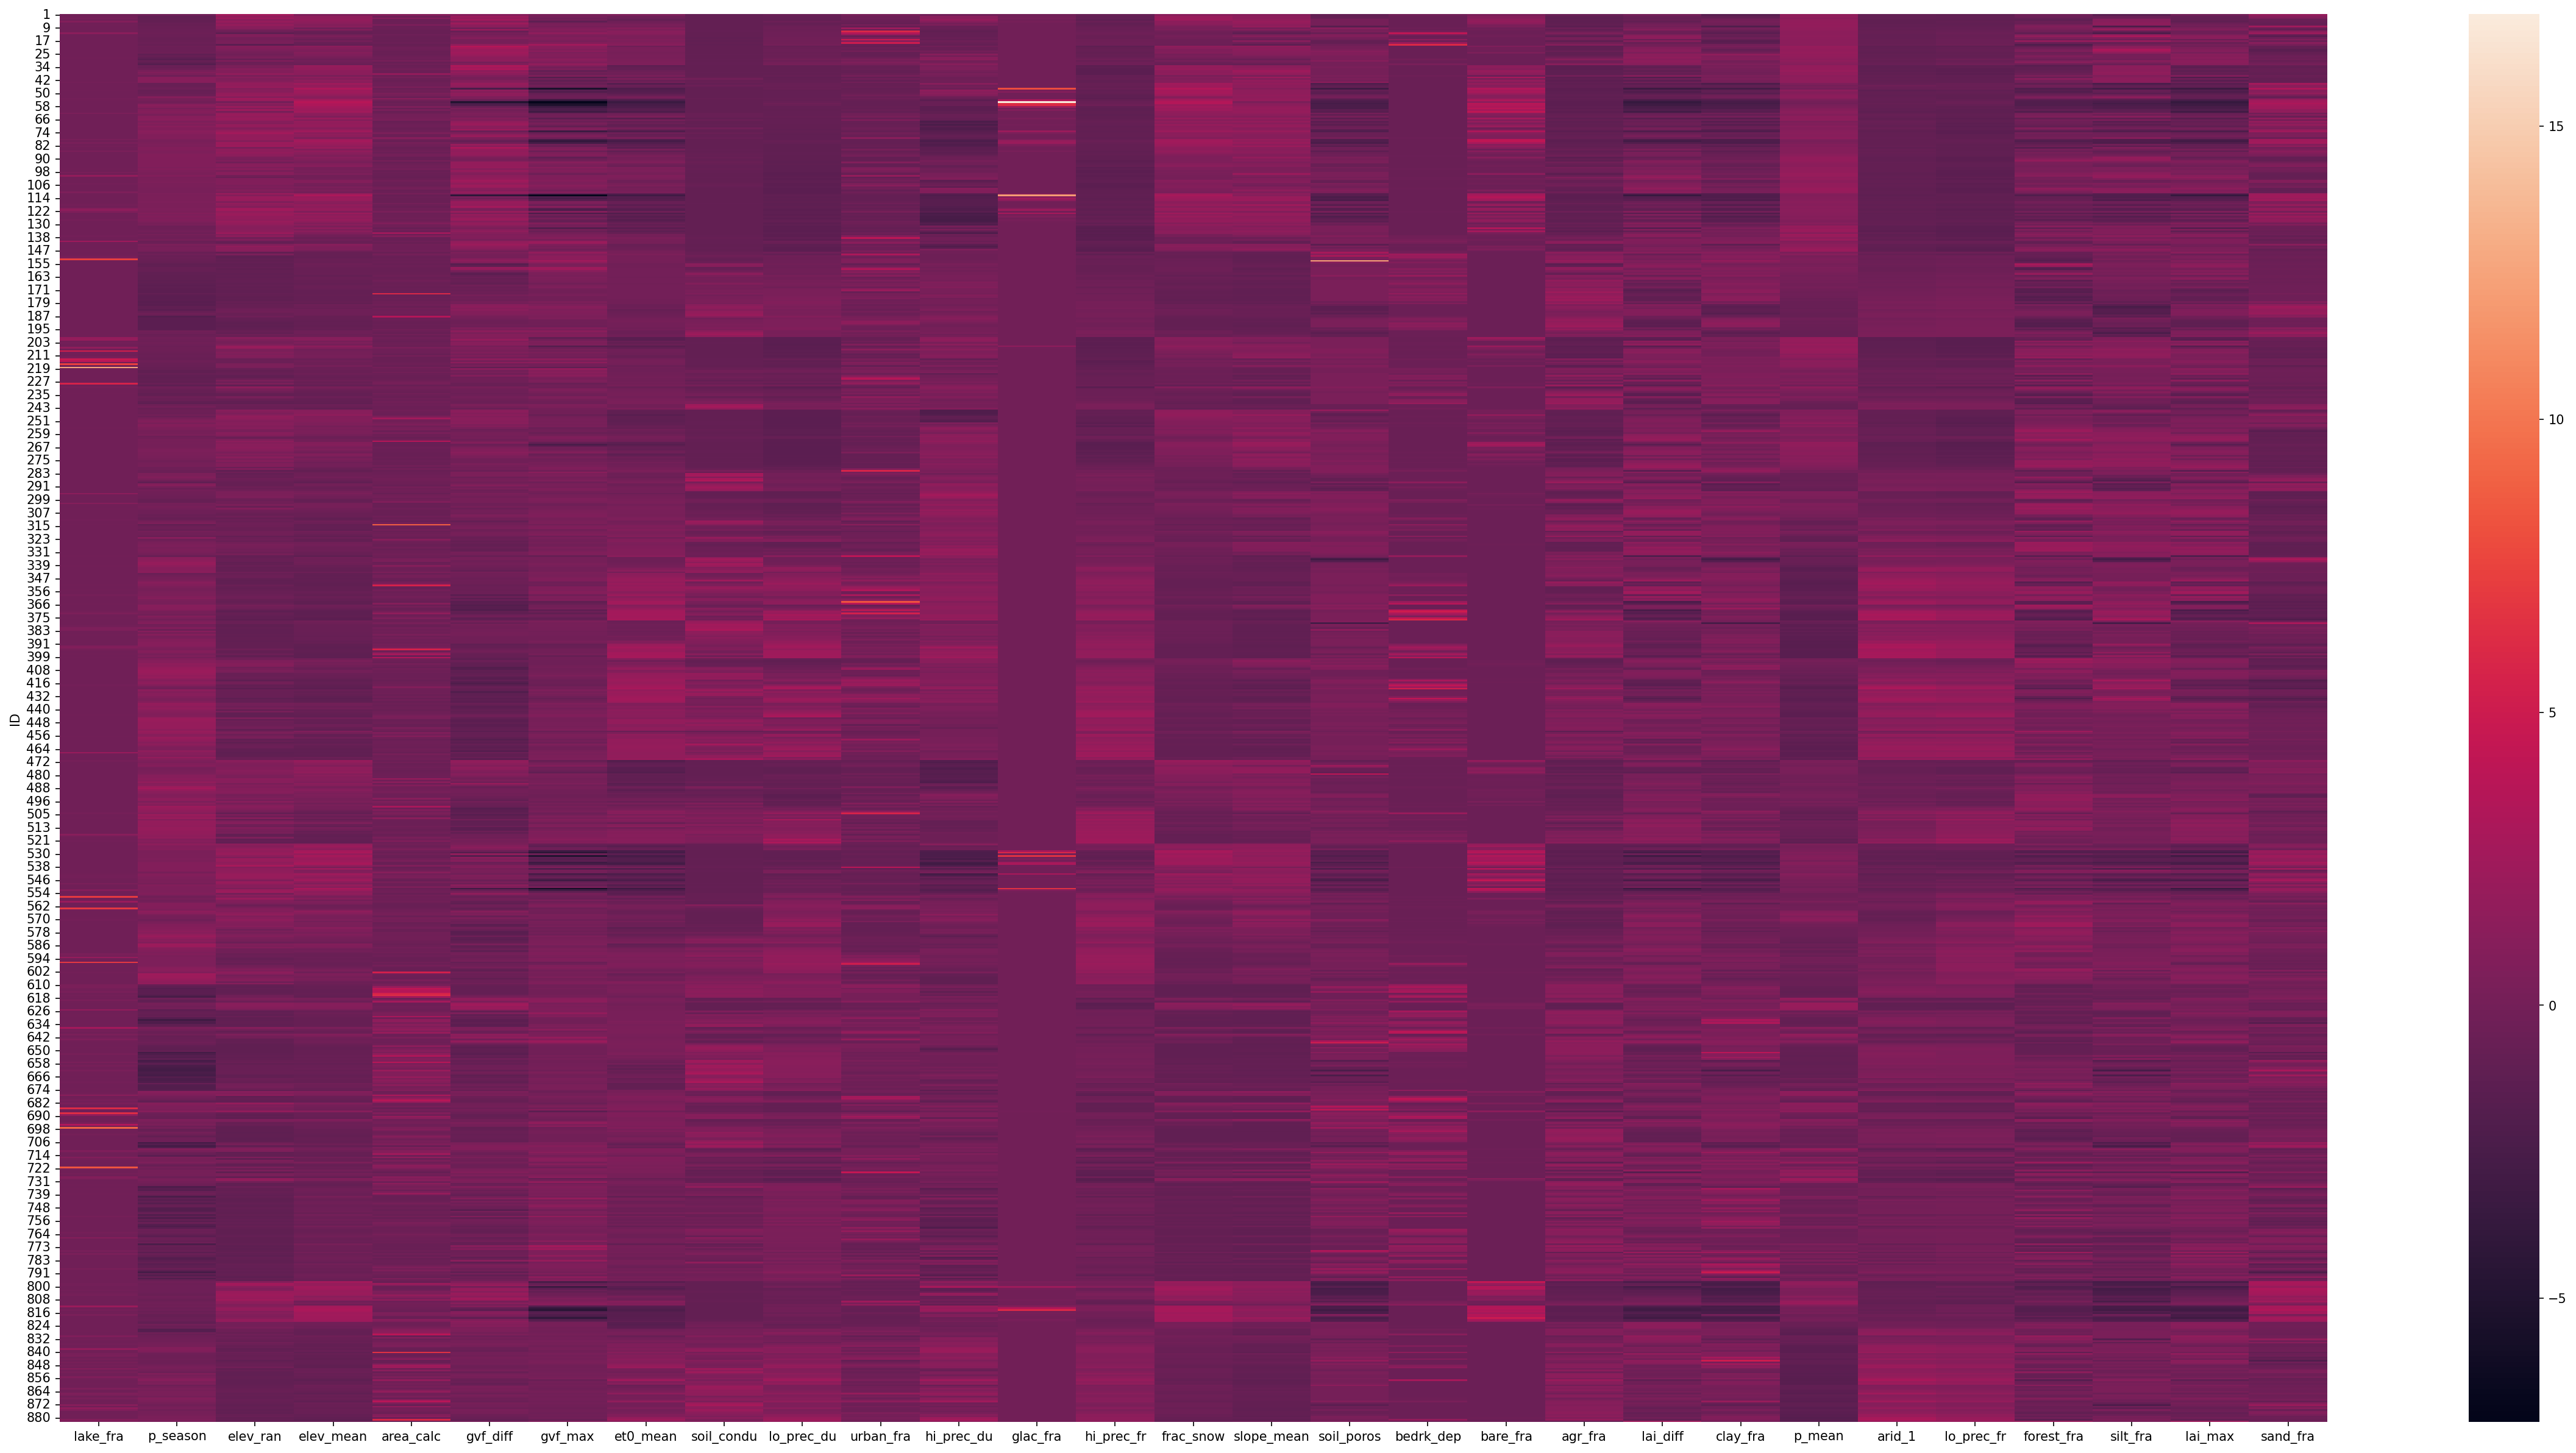

In [65]:
fig, ax = plt.subplots(1, 1, figsize=(40,20))
sns.heatmap(base_attr)

In [67]:
top_ranked_attr_df

NameError: name 'top_ranked_attr_df' is not defined

<Axes: >

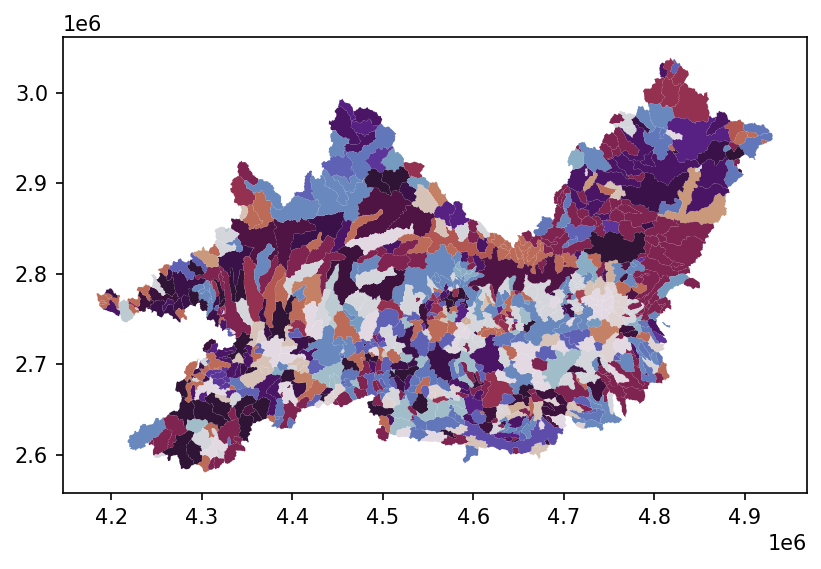

In [105]:
lamah_gdf.plot(column="total_top", cmap="twilight")

<Axes: >

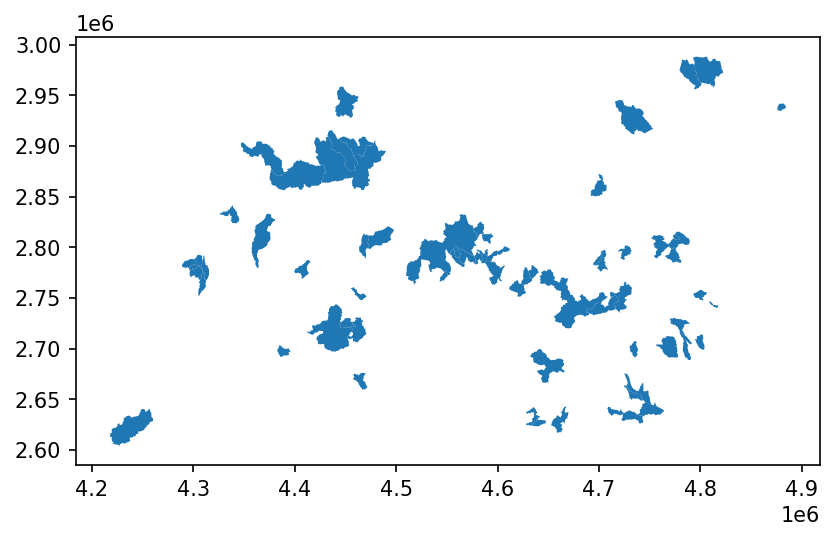

In [122]:
lamah_gdf[lamah_gdf.total_top == "elev_mean"].plot()

<Axes: >

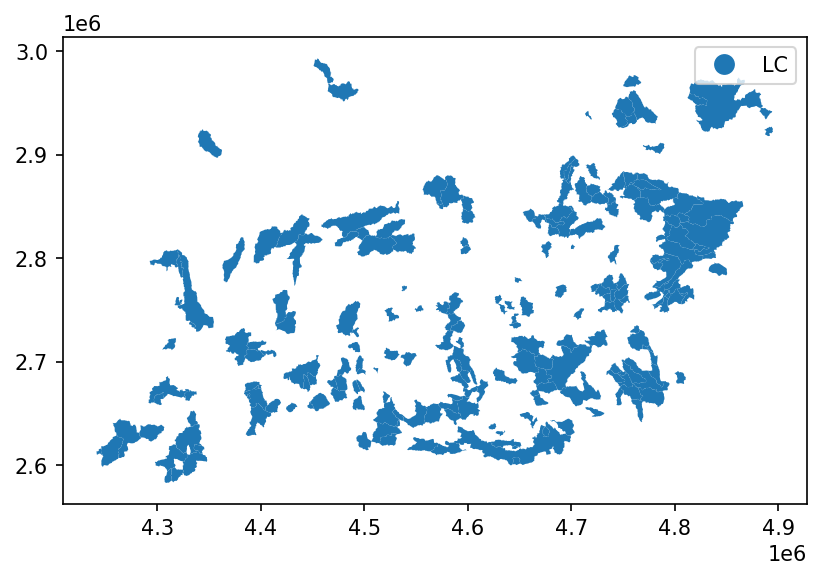

In [119]:
lamah_gdf[lamah_gdf.top_attr_category == "LC"].plot("top_attr_category", legend=True)

In [107]:
noise_level_att_ranking_df = pd.DataFrame(noise_level_att_ranking)

In [ ]:
for bin in noise_level_att_ranking_df.T: 
	
	print(noise_level_att_ranking_df.T[bin].value_counts())

0.01_top
lake_fra      130
p_season       74
area_calc      74
elev_ran       73
elev_mean      63
gvf_diff       49
gvf_max        44
hi_prec_du     41
et0_mean       39
urban_fra      36
lo_prec_du     28
soil_condu     27
hi_prec_fr     26
soil_poros     25
glac_fra       23
frac_snow      21
bare_fra       20
lai_diff       12
agr_fra         9
clay_fra        9
p_mean          9
bedrk_dep       8
lai_max         5
forest_fra      4
slope_mean      3
sand_fra        2
silt_fra        2
arid_1          2
lo_prec_fr      1
Name: count, dtype: int64
0.1_top
lake_fra      144
p_season       75
elev_mean      73
area_calc      72
elev_ran       68
gvf_diff       48
hi_prec_du     45
gvf_max        43
et0_mean       40
urban_fra      38
soil_condu     35
hi_prec_fr     30
lo_prec_du     25
soil_poros     23
bare_fra       19
glac_fra       17
frac_snow      14
clay_fra        9
bedrk_dep       8
lai_diff        8
p_mean          6
agr_fra         5
sand_fra        4
forest_fra      4
lai

### Most importance per strata

In [ ]:
for strata in lamah_gdf.strata.unique(): 
	print(strata)
	print(Counter(lamah_gdf[lamah_gdf.strata == strata].total_top).most_common())

transition
[('p_season', 36), ('urban_fra', 35), ('area_calc', 27), ('et0_mean', 26), ('gvf_diff', 22), ('soil_condu', 20), ('lake_fra', 20), ('elev_ran', 19), ('bare_fra', 17), ('hi_prec_du', 13), ('gvf_max', 11), ('elev_mean', 9), ('hi_prec_fr', 9), ('frac_snow', 8), ('soil_poros', 8), ('glac_fra', 6), ('lo_prec_du', 6), ('clay_fra', 6), ('sand_fra', 3), ('slope_mean', 2), ('bedrk_dep', 1), ('lai_max', 1), ('lo_prec_fr', 1)]
alpine
[('lake_fra', 26), ('elev_ran', 13), ('hi_prec_du', 10), ('area_calc', 9), ('et0_mean', 8), ('soil_poros', 7), ('gvf_diff', 4), ('p_season', 4), ('bare_fra', 4), ('gvf_max', 3), ('urban_fra', 2), ('elev_mean', 2), ('lai_diff', 1), ('soil_condu', 1), ('lo_prec_du', 1)]
plateau
[('lake_fra', 96), ('elev_mean', 59), ('p_season', 48), ('area_calc', 43), ('gvf_diff', 37), ('gvf_max', 20), ('elev_ran', 19), ('hi_prec_fr', 17), ('lo_prec_du', 16), ('hi_prec_du', 16), ('et0_mean', 15), ('bedrk_dep', 11), ('soil_condu', 10), ('lai_diff', 9), ('glac_fra', 7), ('urba

##### Map the variance of each attribute over all levels for the basins

In [57]:
noise_level_nse_var_df = pd.DataFrame(noise_level_nse_var, index=lamah_gdf.index)


In [58]:
total_nse_var_df = pd.DataFrame(total_nse_var)
total_nse_var_df.set_index(lamah_gdf.index, inplace=True)

In [59]:
lamah_gdf_var = lamah_gdf.join(total_nse_var_df)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS


kmeans = KMeans(3, random_state=1277)

cluster_labels = kmeans.fit_predict(lamah_gdf.iloc[:,-31:-2])

lamah_gdf["labels"] = cluster_labels

fig, ax = plt.subplots(3,1, figsize=(10,10))

lamah_gdf.plot(column="labels", ax=ax[0])
lamah_gdf.plot(column="top_attr_category", ax=ax[1], legend=True)
lamah_gdf.plot(column="3rd", ax=ax[2])

plt.tight_layout()

### Gradients

In [ ]:
with open("/home/wuhlmann/BA/data/processed_data/SA/gradients/q_pred_landcover_0903_135428.p", "rb") as f: 
	gradient_dict = pkl.load(f)

In [ ]:
normalized_ranks = {}
for basin, ranks in gradient_dict.items():
	ranks = (ranks - ranks.min()) / (ranks.max() - ranks.min())
	normalized_ranks[basin] = ranks
df = pd.DataFrame(data={basin: ranks for basin, ranks in normalized_ranks.items()})
hierarchy = df.mean(axis=1).sort_values(ascending=False).index

In [ ]:
for basin in df: 

	for attr in df.mean(axis=1).sort_values(ascending=False).index:
		lamah_gdf.loc[int(basin), f"{attr}_basin_rank"] = df.loc[attr, basin]

	lamah_gdf.loc[int(basin), f"top"] = df.loc[:, basin].sort_values(ascending=False).index[0]

In [ ]:
lamah_gdf.top.value_counts()

In [ ]:
fig, axs = plt.subplots(5, 6, figsize=(4*6,4*5))
axs = axs.ravel()

for i, attr in tqdm(zip(range(0,29,1), hierarchy), total=29):
	
	lamah_gdf.plot(column=f"{attr}_basin_rank", ax=axs[i])
	axs[i].set_title(f"{attr}_gradient_rank")


In [ ]:
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/GA.png")